In [1]:
import pandas as pd
from textblob import TextBlob
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the news data
news = pd.read_csv("../data/raw_analyst_ratings.csv")

# Convert date to datetime and drop any rows with invalid or missing dates
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news = news.dropna(subset=['date'])

# Keep only the date part (not time)
news['date'] = news['date'].apply(lambda x: x.date())

# Preview the cleaned data
print(news[['date', 'headline', 'stock']].head())

         date                                           headline stock
0  2020-06-05            Stocks That Hit 52-Week Highs On Friday     A
1  2020-06-03         Stocks That Hit 52-Week Highs On Wednesday     A
2  2020-05-26                      71 Biggest Movers From Friday     A
3  2020-05-22       46 Stocks Moving In Friday's Mid-Day Session     A
4  2020-05-22  B of A Securities Maintains Neutral on Agilent...     A


In [3]:
# Calculate sentiment polarity for each headline using TextBlob
news['sentiment'] = news['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Preview the result
print(news[['headline', 'sentiment']].head())


                                            headline  sentiment
0            Stocks That Hit 52-Week Highs On Friday        0.0
1         Stocks That Hit 52-Week Highs On Wednesday        0.0
2                      71 Biggest Movers From Friday        0.0
3       46 Stocks Moving In Friday's Mid-Day Session        0.0
4  B of A Securities Maintains Neutral on Agilent...        0.0


In [4]:
# Average sentiment by stock and date
sentiment_daily = news.groupby(['stock', 'date'])['sentiment'].mean().reset_index()
sentiment_daily.rename(columns={'sentiment': 'avg_sentiment'}, inplace=True)

# Preview the aggregated sentiment
print(sentiment_daily.head())


  stock        date  avg_sentiment
0     A  2009-04-29            0.0
1     A  2009-06-01            0.0
2     A  2009-07-14            0.0
3     A  2009-07-30            0.0
4     A  2009-08-04            0.0


In [5]:
# List of stock files
stock_files = [
    'AAPL_historical_data.csv',
    'AMZN_historical_data.csv',
    'GOOG_historical_data.csv',
    'META_historical_data.csv',
    'MSFT_historical_data.csv',
    'NVDA_historical_data.csv',
    'TSLA_historical_data.csv'
]

# Function to load, clean, and compute daily return
def load_stock_data(filename):
    stock_name = filename.split('_')[0]
    df = pd.read_csv(f"../data/yfinance_data/{filename}")
    
    # Fix: 'Date' and 'Close' must match column names exactly
    df['date'] = pd.to_datetime(df['Date'], errors='coerce').dt.date
    df = df.dropna(subset=['date', 'Close'])
    
    df.sort_values(by='date', inplace=True)
    df['daily_return'] = df['Close'].pct_change()
    df['stock'] = stock_name
    
    return df[['stock', 'date', 'daily_return']]


In [6]:
# Load all stock data into one DataFrame
stock_data = pd.concat([load_stock_data(file) for file in stock_files], ignore_index=True)

# Preview combined stock data
print(stock_data.head())


  stock        date  daily_return
0  AAPL  1980-12-12           NaN
1  AAPL  1980-12-15     -0.052171
2  AAPL  1980-12-16     -0.073398
3  AAPL  1980-12-17      0.024751
4  AAPL  1980-12-18      0.028992


In [7]:
# Merge sentiment and stock returns
merged = pd.merge(sentiment_daily, stock_data, on=['stock', 'date'], how='inner')

# Drop rows where data is missing (NaNs)
merged.dropna(subset=['avg_sentiment', 'daily_return'], inplace=True)

# Preview merged dataset
print(merged.head())


  stock        date  avg_sentiment  daily_return
0  AAPL  2020-03-09      -0.155556     -0.079092
1  AAPL  2020-03-10       0.021708      0.072022
2  AAPL  2020-03-11       0.018624     -0.034731
3  AAPL  2020-03-12      -0.083048     -0.098755
4  AAPL  2020-03-13       0.069215      0.119808


In [8]:
# Compute correlation between sentiment and return by stock
correlation_results = merged.groupby('stock').apply(
    lambda x: pearsonr(x['avg_sentiment'], x['daily_return'])[0]
).reset_index(name='correlation')

# Show results
print(correlation_results)


  stock  correlation
0  AAPL     0.158900
1  AMZN    -0.029749
2  GOOG     0.056820
3  NVDA     0.103817
4  TSLA     0.082690


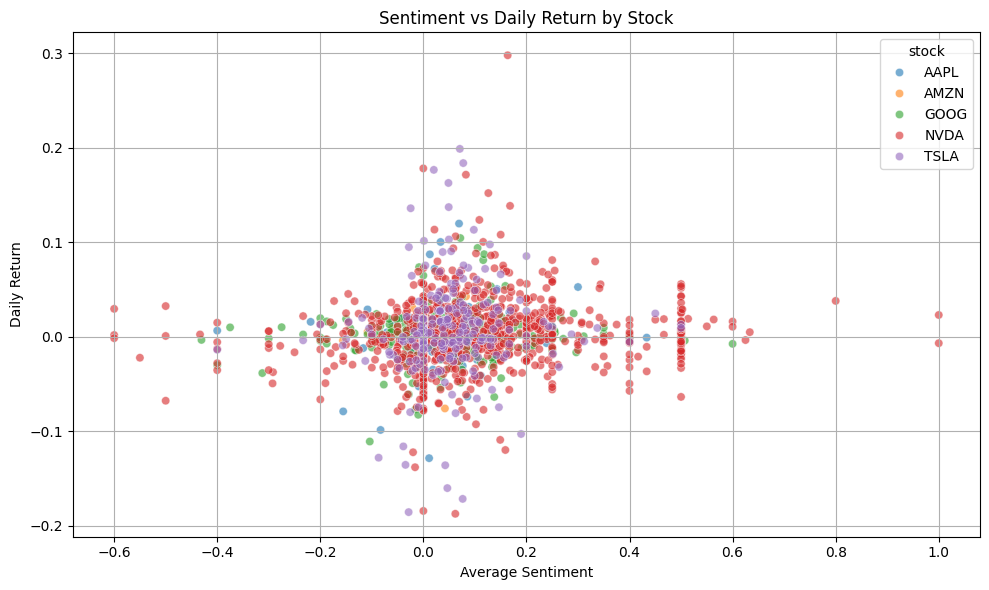

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='avg_sentiment', y='daily_return', hue='stock', alpha=0.6)
plt.title("Sentiment vs Daily Return by Stock")
plt.xlabel("Average Sentiment")
plt.ylabel("Daily Return")
plt.grid(True)
plt.tight_layout()
plt.show()